## Team Members

- Mayank Goyal - 24293916114 - mayankgoyal18052005@ce.du.ac.in
- Vansh Saharawat - 24293916089 - vanshsahara@ce.du.ac.in
- Abeer bartaria - 23293916061 - abeerbartaria@ce.du.ac.in
- Ansh Kumar  - 24293916052 - Anshk3671@gmail.com

# Orbital Debris EDA

This project analyzes orbital debris and satellite catalogs to support a collision-avoidance simulation environment.

Primary objectives:
- profile debris and satellite populations
- clean and standardize source datasets
- produce evidence-driven insights for environment design and evaluation

Datasets used:
- CelesTrak SATCAT
- UCS Satellite Database
- ESA Kelvins "Space Debris: the origin"

## Data Loading and Initial Inspection

Load the raw datasets, verify file availability, and inspect basic structure (shape, columns, sample rows).

In [8]:
from pathlib import Path
import pandas as pd

# Base paths
ROOT = Path.cwd()
RAW_DIR = ROOT / "input_data" / "raw"

# Files used in this analysis
SATCAT_PATH = RAW_DIR / "satcat.csv"
UCS_PATH = RAW_DIR / "satellites.csv"
KELVINS_DIR = RAW_DIR / "space-debris-the-origin"
KELVINS_LABELS_PATH = KELVINS_DIR / "labels_train.dat"

print("Root:", ROOT)
print("Raw data dir:", RAW_DIR)

# 1) Existence checks
required = {
    "satcat": SATCAT_PATH,
    "ucs": UCS_PATH,
    "kelvins_dir": KELVINS_DIR,
    "kelvins_labels": KELVINS_LABELS_PATH,
}

print("\nFile checks:")
for name, path in required.items():
    print(f"- {name}: {'OK' if path.exists() else 'MISSING'} -> {path}")

# 2) Read SATCAT
satcat_df = pd.read_csv(SATCAT_PATH)
print("\nSATCAT shape:", satcat_df.shape)
print("SATCAT columns:", list(satcat_df.columns))
print("SATCAT preview:")
display(satcat_df.head(3))

# 3) Read UCS
# Many UCS exports are semicolon-delimited; we load with ';' first and standardize later.
ucs_df = pd.read_csv(UCS_PATH, sep=";", engine="python")
print("\nUCS shape:", ucs_df.shape)
print("UCS columns (first 15):", list(ucs_df.columns[:15]))
print("UCS preview:")
display(ucs_df.head(3))

# 4) Read Kelvins labels (whitespace-delimited, no header)
# Column meaning from challenge docs:
#   0: originator satellite id
#   1: area-to-mass ratio
#   2..8: epoch/orbital-element values
kelvins_labels = pd.read_csv(KELVINS_LABELS_PATH, sep=r"\s+", header=None)
print("\nKelvins labels shape:", kelvins_labels.shape)
print("Kelvins labels preview:")
display(kelvins_labels.head(5))

Root: /home/mayank/repos/orbits
Raw data dir: /home/mayank/repos/orbits/input_data/raw

File checks:
- satcat: OK -> /home/mayank/repos/orbits/input_data/raw/satcat.csv
- ucs: OK -> /home/mayank/repos/orbits/input_data/raw/satellites.csv
- kelvins_dir: OK -> /home/mayank/repos/orbits/input_data/raw/space-debris-the-origin
- kelvins_labels: OK -> /home/mayank/repos/orbits/input_data/raw/space-debris-the-origin/labels_train.dat

SATCAT shape: (68330, 17)
SATCAT columns: ['OBJECT_NAME', 'OBJECT_ID', 'NORAD_CAT_ID', 'OBJECT_TYPE', 'OPS_STATUS_CODE', 'OWNER', 'LAUNCH_DATE', 'LAUNCH_SITE', 'DECAY_DATE', 'PERIOD', 'INCLINATION', 'APOGEE', 'PERIGEE', 'RCS', 'DATA_STATUS_CODE', 'ORBIT_CENTER', 'ORBIT_TYPE']
SATCAT preview:


,OBJECT_NAME,OBJECT_ID,NORAD_CAT_ID,OBJECT_TYPE,OPS_STATUS_CODE,OWNER,LAUNCH_DATE,LAUNCH_SITE,DECAY_DATE,PERIOD,INCLINATION,APOGEE,PERIGEE,RCS,DATA_STATUS_CODE,ORBIT_CENTER,ORBIT_TYPE
0,SL-1 R/B,1957-001A,1,R/B,D,CIS,1957-10-04,TYMSC,1957-12-01,96.19,65.10,938.0,214.0,20.42,NaN,EA,IMP
1,SPUTNIK 1,1957-001B,2,PAY,D,CIS,1957-10-04,TYMSC,1958-01-03,96.10,65.00,1080.0,64.0,NaN,NaN,EA,IMP
2,SPUTNIK 2,1957-002A,3,PAY,D,CIS,1957-11-03,TYMSC,1958-04-14,103.74,65.33,1659.0,211.0,0.08,NaN,EA,IMP



UCS shape: (7563, 68)
UCS columns (first 15): ['Name of Satellite, Alternate Names', 'Current Official Name of Satellite', 'Country/Org of UN Registry', 'Country of Operator/Owner', 'Operator/Owner', 'Users', 'Purpose', 'Detailed Purpose', 'Class of Orbit', 'Type of Orbit', 'Longitude of GEO (degrees)', 'Perigee (km)', 'Apogee (km)', 'Eccentricity', 'Inclination (degrees)']
UCS preview:


,"Name of Satellite, Alternate Names",Current Official Name of Satellite,Country/Org of UN Registry,Country of Operator/Owner,Operator/Owner,Users,Purpose,Detailed Purpose,Class of Orbit,Type of Orbit,...,Unnamed: 58,Unnamed: 59,Unnamed: 60,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64,Unnamed: 65,Unnamed: 66,Unnamed: 67
0,1HOPSAT-TD (1st-generation High Optical Perfor...,1HOPSAT-TD,NR,USA,Hera Systems,Commercial,Earth Observation,Infrared Imaging,LEO,Non-Polar Inclined,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AAC AIS-Sat1 (Kelpie 1),AAC AIS-Sat1 (Kelpie 1),United Kingdom,United Kingdom,AAC Clyde Space,Commercial,Earth Observation,Automatic Identification System (AIS),LEO,Sun-Synchronous,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Aalto-1,Aalto-1,Finland,Finland,Aalto University,Civil,Technology Development,NaN,LEO,Sun-Synchronous,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Kelvins labels shape: (100, 9)
Kelvins labels preview:


,0,1,2,3,4,5,6,7,8
0,94,10.32583,-3815.0,42260.01,0.047700,11.3705,25.6240,91.5576,9.5178
1,17,20.08288,-3845.0,42260.66,0.008111,8.2732,56.3063,272.0286,45.9370
2,18,0.52148,-7275.0,42252.96,0.099613,2.2224,13.8162,242.1460,166.9770
3,73,41.77603,-4825.0,42258.87,0.057331,15.0011,237.5817,299.0621,72.5915
4,10,3.60228,-6355.0,42249.90,0.091040,6.5579,206.5880,286.8121,329.0498


## UCS Data Preparation

Standardize UCS fields and save cleaned output to `input_data/processed/ucs_clean.csv`.

In [9]:
# Create a working copy of UCS data
ucs_clean = ucs_df.copy()

# Ensure processed output directory exists
PROCESSED_DIR = ROOT / "input_data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# 1) Normalize header spacing
ucs_clean.columns = [c.strip() for c in ucs_clean.columns]

# 2) Drop parser-generated placeholder columns from the raw export
# These often appear as Unnamed:* after parsing rows with trailing separators.
unnamed_cols = [c for c in ucs_clean.columns if c.startswith("Unnamed:")]
ucs_clean = ucs_clean.drop(columns=unnamed_cols, errors="ignore")

# 3) Split combined first field: "Name of Satellite, Alternate Names"
# into two explicit columns where possible.
first_col = "Name of Satellite, Alternate Names"
if first_col in ucs_clean.columns:
    split_cols = ucs_clean[first_col].astype(str).str.split(",", n=1, expand=True)
    ucs_clean["Name of Satellite"] = split_cols[0].str.strip()
    ucs_clean["Alternate Names (raw)"] = split_cols[1].fillna("").str.strip()

# 4) Standardize key numeric-like columns that may contain decimal commas
numeric_candidates = [
    "Perigee (km)",
    "Apogee (km)",
    "Eccentricity",
    "Inclination (degrees)",
    "Period (minutes)",
    "Launch Mass (kg.)",
    "Dry Mass (kg.)",
    "Power (watts)",
]

for col in numeric_candidates:
    if col in ucs_clean.columns:
        ucs_clean[col] = (
            ucs_clean[col]
            .astype(str)
            .str.replace(",", ".", regex=False)
            .str.replace(" ", "", regex=False)
        )
        ucs_clean[col] = pd.to_numeric(ucs_clean[col], errors="coerce")

# 5) Parse launch date
if "Date of Launch" in ucs_clean.columns:
    ucs_clean["Date of Launch"] = pd.to_datetime(
        ucs_clean["Date of Launch"], errors="coerce", dayfirst=True, format="mixed"
    )

# 6) Persist cleaned dataset
ucs_clean_path = PROCESSED_DIR / "ucs_clean.csv"
ucs_clean.to_csv(ucs_clean_path, index=False)

print("Original UCS shape:", ucs_df.shape)
print("Cleaned UCS shape:", ucs_clean.shape)
print("Dropped unnamed columns:", len(unnamed_cols))
print("Saved cleaned file:", ucs_clean_path)

print("\nCleaned columns (first 25):")
print(list(ucs_clean.columns[:25]))

print("\nMissing values (top 10 columns):")
print(ucs_clean.isna().sum().sort_values(ascending=False).head(10))

display(ucs_clean.head(3))

Original UCS shape: (7563, 68)
Cleaned UCS shape: (7563, 38)
Dropped unnamed columns: 32
Saved cleaned file: /home/mayank/repos/orbits/input_data/processed/ucs_clean.csv

Cleaned columns (first 25):
['Name of Satellite, Alternate Names', 'Current Official Name of Satellite', 'Country/Org of UN Registry', 'Country of Operator/Owner', 'Operator/Owner', 'Users', 'Purpose', 'Detailed Purpose', 'Class of Orbit', 'Type of Orbit', 'Longitude of GEO (degrees)', 'Perigee (km)', 'Apogee (km)', 'Eccentricity', 'Inclination (degrees)', 'Period (minutes)', 'Launch Mass (kg.)', 'Dry Mass (kg.)', 'Power (watts)', 'Date of Launch', 'Expected Lifetime (yrs.)', 'Contractor', 'Country of Contractor', 'Launch Site', 'Launch Vehicle']

Missing values (top 10 columns):
Power (watts)       7335
Source.6            7060
Source.5            7010
Source.1            6838
Source.4            6835
Dry Mass (kg.)      6799
Source.3            6438
Detailed Purpose    6308
Source.2            5732
Comments         

,"Name of Satellite, Alternate Names",Current Official Name of Satellite,Country/Org of UN Registry,Country of Operator/Owner,Operator/Owner,Users,Purpose,Detailed Purpose,Class of Orbit,Type of Orbit,...,Source Used for Orbital Data,Source,Source.1,Source.2,Source.3,Source.4,Source.5,Source.6,Name of Satellite,Alternate Names (raw)
0,1HOPSAT-TD (1st-generation High Optical Perfor...,1HOPSAT-TD,NR,USA,Hera Systems,Commercial,Earth Observation,Infrared Imaging,LEO,Non-Polar Inclined,...,JMSatcat/3_20,https://spaceflig htnow.com/2019/12/11/indias-...,https://www.herasys.com/,NaN,NaN,NaN,NaN,NaN,1HOPSAT-TD (1st-generation High Optical Perfor...,
1,AAC AIS-Sat1 (Kelpie 1),AAC AIS-Sat1 (Kelpie 1),United Kingdom,United Kingdom,AAC Clyde Space,Commercial,Earth Observation,Automatic Identification System (AIS),LEO,Sun-Synchronous,...,JMSatcat/9_23,https://www.aac-clyde.space/articles/aac-clyde...,NaN,NaN,NaN,NaN,NaN,NaN,AAC AIS-Sat1 (Kelpie 1),
2,Aalto-1,Aalto-1,Finland,Finland,Aalto University,Civil,Technology Development,NaN,LEO,Sun-Synchronous,...,JMSatcat/10_17,https://directory.eoportal.org/web/eoportal/sa...,NaN,http://www.planet4589.org/space/log/satcat.txt,NaN,NaN,NaN,NaN,Aalto-1,


## SATCAT Preparation

Standardize SATCAT fields and save a cleaned table to `input_data/processed/satcat_clean.csv`.

In [10]:
satcat_clean = satcat_df.copy()

for date_col in ["LAUNCH_DATE", "DECAY_DATE"]:
    if date_col in satcat_clean.columns:
        satcat_clean[date_col] = pd.to_datetime(satcat_clean[date_col], errors="coerce")

numeric_satcat = ["PERIOD", "INCLINATION", "APOGEE", "PERIGEE", "RCS"]
for col in numeric_satcat:
    if col in satcat_clean.columns:
        satcat_clean[col] = pd.to_numeric(satcat_clean[col], errors="coerce")

satcat_clean_path = PROCESSED_DIR / "satcat_clean.csv"
satcat_clean.to_csv(satcat_clean_path, index=False)

print("SATCAT original:", satcat_df.shape)
print("SATCAT cleaned:", satcat_clean.shape)
print("Saved:", satcat_clean_path)
display(satcat_clean.head(3))

SATCAT original: (68330, 17)
SATCAT cleaned: (68330, 17)
Saved: /home/mayank/repos/orbits/input_data/processed/satcat_clean.csv


,OBJECT_NAME,OBJECT_ID,NORAD_CAT_ID,OBJECT_TYPE,OPS_STATUS_CODE,OWNER,LAUNCH_DATE,LAUNCH_SITE,DECAY_DATE,PERIOD,INCLINATION,APOGEE,PERIGEE,RCS,DATA_STATUS_CODE,ORBIT_CENTER,ORBIT_TYPE
0,SL-1 R/B,1957-001A,1,R/B,D,CIS,1957-10-04,TYMSC,1957-12-01,96.19,65.10,938.0,214.0,20.42,NaN,EA,IMP
1,SPUTNIK 1,1957-001B,2,PAY,D,CIS,1957-10-04,TYMSC,1958-01-03,96.10,65.00,1080.0,64.0,NaN,NaN,EA,IMP
2,SPUTNIK 2,1957-002A,3,PAY,D,CIS,1957-11-03,TYMSC,1958-04-14,103.74,65.33,1659.0,211.0,0.08,NaN,EA,IMP


## Kelvins Preparation

Parse labels and trajectory files, then save processed outputs under `input_data/processed`.

In [11]:
from pathlib import Path

kelvins_labels_clean = kelvins_labels.copy()
kelvins_labels_clean.columns = [
    "originator_id",
    "area_to_mass_ratio",
    "feature_2",
    "feature_3",
    "semi_major_axis_km",
    "eccentricity",
    "inclination_deg",
    "mean_anomaly_deg",
    "raan_or_arg_deg",
]

kelvins_labels_path = PROCESSED_DIR / "kelvins_labels_clean.csv"
kelvins_labels_clean.to_csv(kelvins_labels_path, index=False)


def read_kelvins_folder(folder_path: Path):
    files = sorted(folder_path.glob("*.dat"))
    frames = []
    for file in files:
        temp = pd.read_csv(file, sep=r"\s+", header=None)
        temp["trajectory_file"] = file.name
        temp["trajectory_id"] = file.stem
        frames.append(temp)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

kelvins_deb_train = read_kelvins_folder(KELVINS_DIR / "deb_train")
kelvins_deb_test = read_kelvins_folder(KELVINS_DIR / "deb_test")
kelvins_sat = read_kelvins_folder(KELVINS_DIR / "sat")

kelvins_deb_train.to_csv(PROCESSED_DIR / "kelvins_deb_train_long.csv", index=False)
kelvins_deb_test.to_csv(PROCESSED_DIR / "kelvins_deb_test_long.csv", index=False)
kelvins_sat.to_csv(PROCESSED_DIR / "kelvins_sat_long.csv", index=False)

print("Kelvins labels shape:", kelvins_labels_clean.shape)
print("Kelvins deb_train shape:", kelvins_deb_train.shape)
print("Kelvins deb_test shape:", kelvins_deb_test.shape)
print("Kelvins sat shape:", kelvins_sat.shape)
print("Saved label file:", kelvins_labels_path)

Kelvins labels shape: (100, 9)
Kelvins deb_train shape: (751, 9)
Kelvins deb_test shape: (751, 9)
Kelvins sat shape: (109600, 9)
Saved label file: /home/mayank/repos/orbits/input_data/processed/kelvins_labels_clean.csv


## Data Quality Summary

Create compact quality tables for cleaned SATCAT, cleaned UCS, and Kelvins labels.

In [12]:
def quality_table(df: pd.DataFrame, name: str) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "dataset": [name],
            "rows": [len(df)],
            "columns": [df.shape[1]],
            "duplicate_rows": [int(df.duplicated().sum())],
            "missing_cells": [int(df.isna().sum().sum())],
            "missing_pct": [round(df.isna().sum().sum() / (df.shape[0] * df.shape[1]) * 100, 2)],
        }
    )

quality_overview = pd.concat(
    [
        quality_table(satcat_clean, "satcat_clean"),
        quality_table(ucs_clean, "ucs_clean"),
        quality_table(kelvins_labels_clean, "kelvins_labels_clean"),
    ],
    ignore_index=True,
)

display(quality_overview)

missing_by_dataset = {
    "satcat_clean": satcat_clean.isna().sum().sort_values(ascending=False).head(10),
    "ucs_clean": ucs_clean.isna().sum().sort_values(ascending=False).head(10),
    "kelvins_labels_clean": kelvins_labels_clean.isna().sum().sort_values(ascending=False).head(10),
}

for name, series in missing_by_dataset.items():
    print(f"\nTop missing columns in {name}:")
    print(series)

,dataset,rows,columns,duplicate_rows,missing_cells,missing_pct
0,satcat_clean,68330,17,0,156098,13.44
1,ucs_clean,7563,38,7,74207,25.82
2,kelvins_labels_clean,100,9,0,0,0.00



Top missing columns in satcat_clean:
DATA_STATUS_CODE    67072
RCS                 35399
DECAY_DATE          33383
OPS_STATUS_CODE     16560
INCLINATION           921
APOGEE                921
PERIOD                921
PERIGEE               921
OBJECT_NAME             0
LAUNCH_SITE             0
dtype: int64

Top missing columns in ucs_clean:
Power (watts)       7335
Source.6            7060
Source.5            7010
Source.1            6838
Source.4            6835
Dry Mass (kg.)      6799
Source.3            6438
Detailed Purpose    6308
Source.2            5732
Comments            5478
dtype: int64

Top missing columns in kelvins_labels_clean:
originator_id         0
area_to_mass_ratio    0
feature_2             0
feature_3             0
semi_major_axis_km    0
eccentricity          0
inclination_deg       0
mean_anomaly_deg      0
raan_or_arg_deg       0
dtype: int64


## SATCAT Analysis

Summarize object composition and temporal launch trend.

,OBJECT_TYPE,count
0,DEB,35750
1,PAY,25588
2,R/B,6828
3,UNK,164


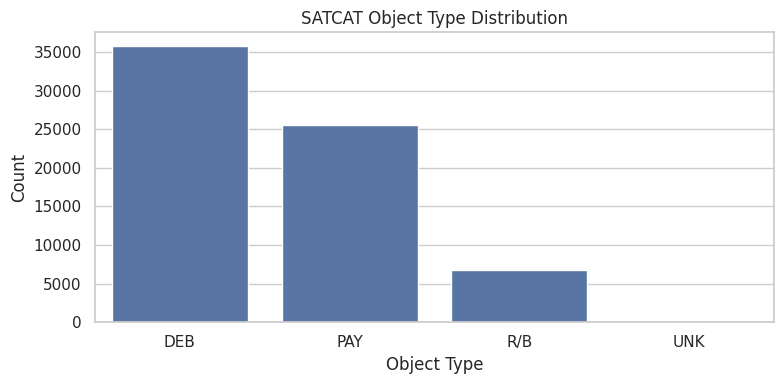

,launch_year,count
55,2012,474
56,2013,432
57,2014,542
58,2015,338
59,2016,355
60,2017,524
61,2018,963
62,2019,783
63,2020,1436
64,2021,2006


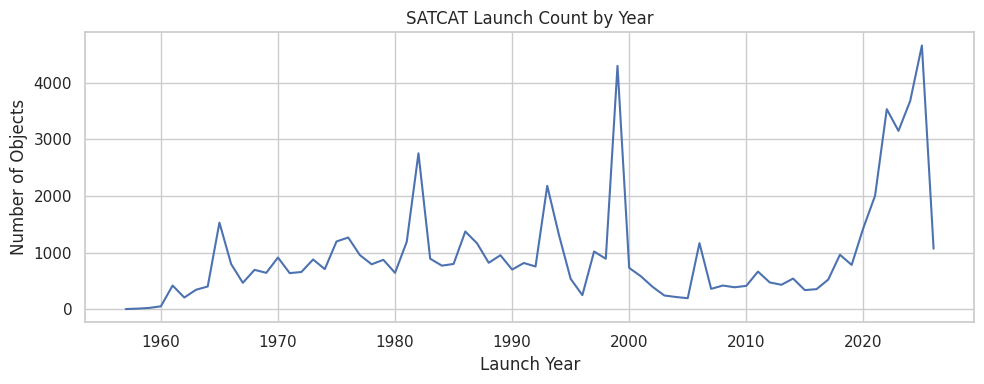

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Object type distribution
obj_counts = satcat_clean["OBJECT_TYPE"].fillna("UNKNOWN").value_counts().reset_index()
obj_counts.columns = ["OBJECT_TYPE", "count"]

display(obj_counts)

plt.figure(figsize=(8, 4))
sns.barplot(data=obj_counts, x="OBJECT_TYPE", y="count")
plt.title("SATCAT Object Type Distribution")
plt.xlabel("Object Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Launch trend by year
launch_year_counts = (
    satcat_clean.dropna(subset=["LAUNCH_DATE"])
    .assign(launch_year=satcat_clean["LAUNCH_DATE"].dt.year)
    .groupby("launch_year")
    .size()
    .reset_index(name="count")
)

display(launch_year_counts.tail(15))

plt.figure(figsize=(10, 4))
sns.lineplot(data=launch_year_counts, x="launch_year", y="count")
plt.title("SATCAT Launch Count by Year")
plt.xlabel("Launch Year")
plt.ylabel("Number of Objects")
plt.tight_layout()
plt.show()

## UCS Analysis

Summarize operational satellite purpose, orbit class, and launch trend.

,Purpose,count
0,Communications,5514
1,Earth Observation,1235
2,Technology Development,372
3,Navigation/Global Positioning,142
4,Space Science,99
5,Technology Demonstration,64
6,Earth Science,28
7,Surveillance,20
8,Navigation/Regional Positioning,13
9,Unknown,12


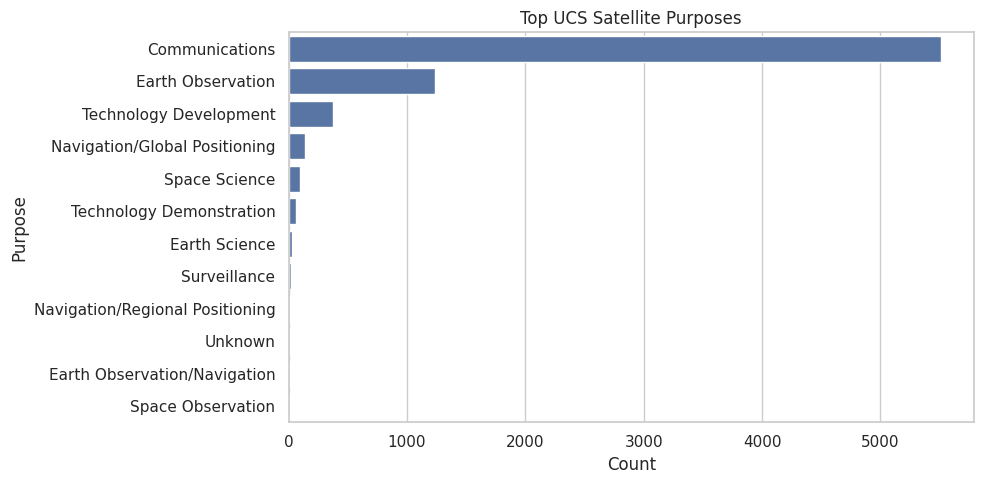

,Class of Orbit,count
0,LEO,6768
1,GEO,589
2,MEO,143
3,ELLIPTICAL,59
4,OTHER/UNKNOWN,4


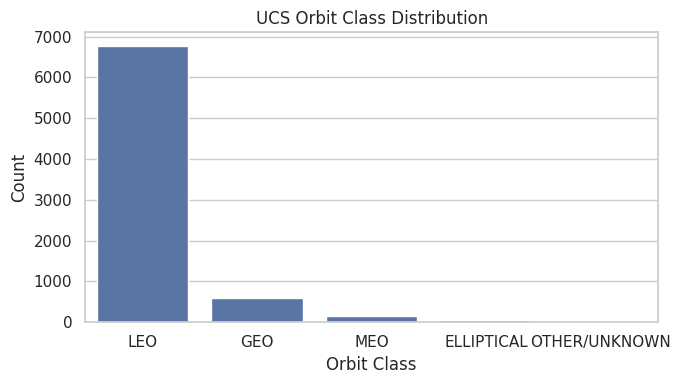

,launch_year,count
21,2009,57
22,2010,66
23,2011,84
24,2012,79
25,2013,95
26,2014,117
27,2015,132
28,2016,107
29,2017,221
30,2018,308


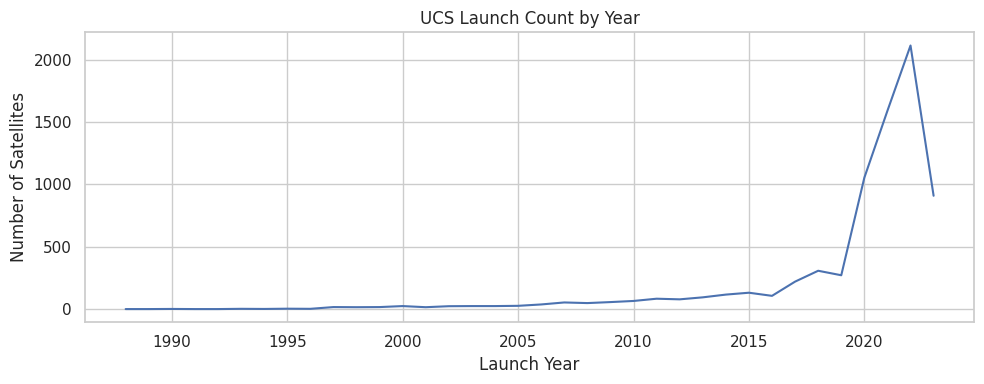

In [17]:
ucs_purpose = (
    ucs_clean["Purpose"].fillna("Unknown").value_counts().reset_index()
)
ucs_purpose.columns = ["Purpose", "count"]
display(ucs_purpose.head(15))

plt.figure(figsize=(10, 5))
sns.barplot(data=ucs_purpose.head(12), x="count", y="Purpose")
plt.title("Top UCS Satellite Purposes")
plt.xlabel("Count")
plt.ylabel("Purpose")
plt.tight_layout()
plt.show()

orbit_norm = (
    ucs_clean["Class of Orbit"]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({"LEO": "LEO", "LEO ": "LEO", "LEOO": "LEO", "LEO": "LEO", "LEO": "LEO"})
)
orbit_norm = orbit_norm.where(orbit_norm.isin(["LEO", "MEO", "GEO", "ELLIPTICAL"]), "OTHER/UNKNOWN")
ucs_orbit = orbit_norm.value_counts().reset_index()
ucs_orbit.columns = ["Class of Orbit", "count"]
display(ucs_orbit)

plt.figure(figsize=(7, 4))
sns.barplot(data=ucs_orbit, x="Class of Orbit", y="count")
plt.title("UCS Orbit Class Distribution")
plt.xlabel("Orbit Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

ucs_launch_year = (
    ucs_clean.dropna(subset=["Date of Launch"])
    .assign(launch_year=lambda d: d["Date of Launch"].dt.year)
)
ucs_launch_year = ucs_launch_year[
    (ucs_launch_year["launch_year"] >= 1957) & (ucs_launch_year["launch_year"] <= 2035)
]
ucs_launch_year = (
    ucs_launch_year.groupby("launch_year").size().reset_index(name="count")
)

display(ucs_launch_year.tail(15))

plt.figure(figsize=(10, 4))
sns.lineplot(data=ucs_launch_year, x="launch_year", y="count")
plt.title("UCS Launch Count by Year")
plt.xlabel("Launch Year")
plt.ylabel("Number of Satellites")
plt.tight_layout()
plt.show()

## Kelvins Analysis

Debris-vs-satellite class balance and basic orbital element distributions.

,count,mean,std,min,25%,50%,75%,max,missing_ratio
originator_id,100.0,49.700000,29.211005,1.00000,21.750000,49.500000,75.250000,100.00000,0.0
area_to_mass_ratio,100.0,10.983837,12.867690,0.31969,1.764633,4.989640,18.281610,49.92149,0.0
feature_2,100.0,-3604.300000,2147.024370,-7295.00000,-5220.000000,-3565.000000,-1872.500000,-5.00000,0.0
feature_3,100.0,42254.820000,3.662704,42247.85000,42251.757500,42254.700000,42257.900000,42262.44000,0.0
semi_major_axis_km,100.0,0.052836,0.027862,0.00459,0.027844,0.055848,0.070015,0.10909,0.0
eccentricity,100.0,9.644671,4.730841,1.35230,5.992275,9.588400,13.396050,22.33870,0.0
inclination_deg,100.0,163.251015,111.376679,0.63820,68.921200,152.959700,247.065700,351.24760,0.0
mean_anomaly_deg,100.0,189.424480,95.798442,2.22560,105.347325,190.396350,263.455075,356.51910,0.0
raan_or_arg_deg,100.0,90.134697,91.359688,4.41410,32.582625,59.556000,102.013650,355.28980,0.0


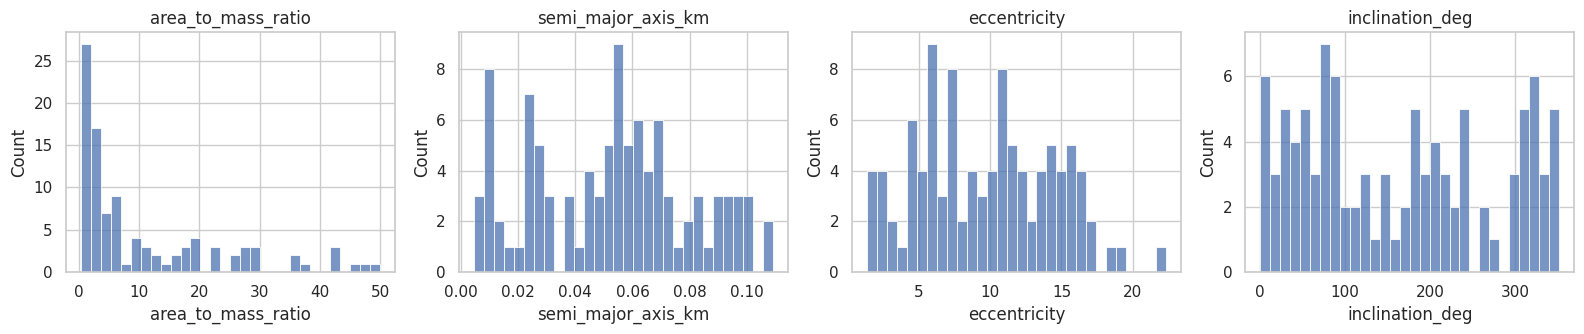

,subset,rows,trajectories,avg_points_per_trajectory
0,deb_train,751,100,7.51
1,deb_test,751,100,7.51
2,sat,109600,100,1096.00


In [18]:
kelvins_numeric = kelvins_labels_clean.apply(pd.to_numeric, errors="coerce")
kelvins_stats = kelvins_numeric.describe().T
kelvins_stats["missing_ratio"] = kelvins_numeric.isna().mean()
display(kelvins_stats)

kelvins_plot_cols = [
    "area_to_mass_ratio",
    "semi_major_axis_km",
    "eccentricity",
    "inclination_deg",
]
kelvins_plot_cols = [c for c in kelvins_plot_cols if c in kelvins_numeric.columns]

if kelvins_plot_cols:
    fig, axes = plt.subplots(1, len(kelvins_plot_cols), figsize=(4 * len(kelvins_plot_cols), 3.5))
    if len(kelvins_plot_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, kelvins_plot_cols):
        sns.histplot(kelvins_numeric[col].dropna(), bins=30, kde=False, ax=ax)
        ax.set_title(col)
    plt.tight_layout()
    plt.show()

trajectory_summary = pd.DataFrame(
    [
        {
            "subset": "deb_train",
            "rows": len(kelvins_deb_train),
            "trajectories": kelvins_deb_train["trajectory_id"].nunique(),
            "avg_points_per_trajectory": round(len(kelvins_deb_train) / max(kelvins_deb_train["trajectory_id"].nunique(), 1), 2),
        },
        {
            "subset": "deb_test",
            "rows": len(kelvins_deb_test),
            "trajectories": kelvins_deb_test["trajectory_id"].nunique(),
            "avg_points_per_trajectory": round(len(kelvins_deb_test) / max(kelvins_deb_test["trajectory_id"].nunique(), 1), 2),
        },
        {
            "subset": "sat",
            "rows": len(kelvins_sat),
            "trajectories": kelvins_sat["trajectory_id"].nunique(),
            "avg_points_per_trajectory": round(len(kelvins_sat) / max(kelvins_sat["trajectory_id"].nunique(), 1), 2),
        },
    ]
)
display(trajectory_summary)

## Integrated Findings

Final EDA summary and checks for modeling-ready artifacts.

In [19]:
summary_points = pd.DataFrame(
    [
        {
            "dataset": "SATCAT",
            "rows": len(satcat_clean),
            "notes": "Large historical object catalog; object types and launch trends available",
        },
        {
            "dataset": "UCS",
            "rows": len(ucs_clean),
            "notes": "Operational context with purpose and orbit class metadata",
        },
        {
            "dataset": "Kelvins",
            "rows": len(kelvins_labels_clean),
            "notes": "Labeled orbital features plus long-form trajectory files",
        },
    ]
)

display(summary_points)

expected_outputs = [
    PROCESSED_DIR / "satcat_clean.csv",
    PROCESSED_DIR / "ucs_clean.csv",
    PROCESSED_DIR / "kelvins_labels_clean.csv",
    PROCESSED_DIR / "kelvins_deb_train_long.csv",
    PROCESSED_DIR / "kelvins_deb_test_long.csv",
    PROCESSED_DIR / "kelvins_sat_long.csv",
]

outputs_status = pd.DataFrame(
    {
        "file": [p.name for p in expected_outputs],
        "exists": [p.exists() for p in expected_outputs],
    }
)
display(outputs_status)

print("EDA complete: cleaned artifacts are ready under input_data/processed/")

,dataset,rows,notes
0,SATCAT,68330,Large historical object catalog; object types ...
1,UCS,7563,Operational context with purpose and orbit cla...
2,Kelvins,100,Labeled orbital features plus long-form trajec...


,file,exists
0,satcat_clean.csv,True
1,ucs_clean.csv,True
2,kelvins_labels_clean.csv,True
3,kelvins_deb_train_long.csv,True
4,kelvins_deb_test_long.csv,True
5,kelvins_sat_long.csv,True


EDA complete: cleaned artifacts are ready under input_data/processed/
